In [1]:
import pandas as pd 
import numpy as np
import torch
from collections import OrderedDict
from typing import Dict, List, Tuple

In [2]:
# =============================================================================
# Konfigurasi path dataset
# =============================================================================
BASE_DIR = r"C:\Users\s2\Documents\Federated\dataset"

PATHS = {
    "drebin": f"{BASE_DIR}/drebin-215-dataset-5560malware-9476-benign.csv",
    "kronodroid": f"{BASE_DIR}/kronodroid.csv",
    "malgenome": f"{BASE_DIR}/malgenome.csv",
    "tuandromd": f"{BASE_DIR}/TUANDROMD 2.csv",
}

# =============================================================================
# Fungsi bantu
# =============================================================================
def load_raw(path: str) -> pd.DataFrame:
    """Baca CSV dan buang kolom index bawaan ('Unnamed: 0') kalau ada."""
    data = pd.read_csv(path)
    if "Unnamed: 0" in data.columns:
        data = data.drop(columns=["Unnamed: 0"])
    return data

def encode_label(data: pd.DataFrame, label_col: str, mapping: Dict) -> pd.DataFrame:
    """Encode kolom label sesuai mapping, mis. {'B': 0, 'S': 1}."""
    data = data.copy()
    data[label_col] = data[label_col].replace(mapping)
    return data

def to_numeric_features(data: pd.DataFrame, label_col: str) -> pd.DataFrame:
    """Paksa semua kolom selain label jadi numerik; nilai gagal -> NaN."""
    data = data.copy()
    feature_columns = [c for c in data.columns if c != label_col]
    data[feature_columns] = data[feature_columns].apply(pd.to_numeric, errors="coerce")
    return data

def report(name: str, X: np.ndarray, y: np.ndarray) -> None:
    print(f"[{name}]")
    print("  Ukuran X       :", X.shape)
    print("  Ukuran y       :", y.shape)
    print("  Distribusi kelas:", np.bincount(y))
    print()

def split_features_labels(
    data: pd.DataFrame, label_col: str
) -> Tuple[np.ndarray, np.ndarray]:
    X = data.drop(columns=[label_col]).values.astype(np.float32)
    y = data[label_col].astype(int).values
    return X, y

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from dataset import split_and_prepare_data
# =============================================================================
# 1. Dataset Drebin
# =============================================================================
LABEL_COLUMN = "class"  # sesuaikan dengan nama kolom label sebenarnya di file Drebin
SPECIAL_COLUMN = "TelephonyManager.getSimCountryIso"
 
data = load_raw(PATHS["drebin"])
 
if SPECIAL_COLUMN in data.columns:
    data[SPECIAL_COLUMN] = data[SPECIAL_COLUMN].replace("?", np.nan)
    data[SPECIAL_COLUMN] = pd.to_numeric(data[SPECIAL_COLUMN], errors="coerce")
 
if LABEL_COLUMN not in data.columns:
    raise KeyError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan. Kolom tersedia: {list(data.columns)}")
 
data = encode_label(data, LABEL_COLUMN, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COLUMN)
data = data.dropna().reset_index(drop=True)
 
X_drebin, y_drebin = split_features_labels(data, LABEL_COLUMN)
N_CLASSES = len(np.unique(y_drebin))
N_FEATURES = X_drebin.shape[1]
 
report("Drebin", X_drebin, y_drebin)
print("Jumlah kelas:", N_CLASSES)
 
drebin_split = split_and_prepare_data(X_drebin, y_drebin)
 
# =============================================================================
# 2. Dataset KronoDroid
# =============================================================================
LABEL_COL_KRONO = "Malware"
data = load_raw(PATHS["kronodroid"])
print("Ukuran data awal:", data.shape)
print("\nMissing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("\nNilai unik Malware:", data[LABEL_COL_KRONO].unique())
print("Distribusi kelas Malware:\n", data[LABEL_COL_KRONO].value_counts())
 
data = to_numeric_features(data, LABEL_COL_KRONO)
data = data.dropna().reset_index(drop=True)
 
X_krono, y_krono = split_features_labels(data, LABEL_COL_KRONO)
target_names_krono = ["goodware", "malware"]
 
report("KronoDroid", X_krono, y_krono)
print("Jumlah fitur:", X_krono.shape[1])
 
krono_split = split_and_prepare_data(X_krono, y_krono)

# =============================================================================
# 3. Dataset MalGenome
# =============================================================================
LABEL_COL_MALGENOME = "class"
 
data = load_raw(PATHS["malgenome"])
print("Missing value per kolom:\n", data.isna().sum())
 
data = encode_label(data, LABEL_COL_MALGENOME, {"B": 0, "S": 1})
data = to_numeric_features(data, LABEL_COL_MALGENOME)
data = data.dropna().reset_index(drop=True)
 
X_malgenome, y_malgenome = split_features_labels(data, LABEL_COL_MALGENOME)
target_names_malgenome = ["benign", "malware"]
 
report("MalGenome", X_malgenome, y_malgenome)
 
malgenome_split = split_and_prepare_data(X_malgenome, y_malgenome)

# =============================================================================
# 4. Dataset TUANDROMD
# =============================================================================
LABEL_COL_TUANDROMD = "Label"
 
data = load_raw(PATHS["tuandromd"])
print("Missing value sebelum drop:", data.isna().sum().sum())
 
data = data.dropna().reset_index(drop=True)
print("Missing value setelah drop:", data.isna().sum().sum())
 
print("Nilai unik Label:", data[LABEL_COL_TUANDROMD].unique())
 
data = encode_label(data, LABEL_COL_TUANDROMD, {"goodware": 0, "malware": 1})
data = to_numeric_features(data, LABEL_COL_TUANDROMD)
data = data.dropna().reset_index(drop=True)
 
X_tuandromd, y_tuandromd = split_features_labels(data, LABEL_COL_TUANDROMD)
target_names_tuandromd = ["goodware", "malware"]
 
report("TUANDROMD", X_tuandromd, y_tuandromd)

tuandromd_split = split_and_prepare_data(X_tuandromd, y_tuandromd)

C:\Users\s2\AppData\Local\Temp\ipykernel_23396\1734278083.py:18: DtypeWarning: Columns (92: TelephonyManager.getSimCountryIso) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


[Drebin]
  Ukuran X       : (15031, 215)
  Ukuran y       : (15031,)
  Distribusi kelas: [9476 5555]

Jumlah kelas: 2
Train: torch.Size([10521, 215]) | Val: torch.Size([2255, 215]) | Test: torch.Size([2255, 215])
Ukuran data awal: (78137, 463)

Missing value sebelum drop: 0
Missing value setelah drop: 0

Nilai unik Malware: [1 0]
Distribusi kelas Malware:
 Malware
1    41382
0    36755
Name: count, dtype: int64
[KronoDroid]
  Ukuran X       : (78137, 462)
  Ukuran y       : (78137,)
  Distribusi kelas: [36755 41382]

Jumlah fitur: 462
Train: torch.Size([54695, 462]) | Val: torch.Size([11721, 462]) | Test: torch.Size([11721, 462])
Missing value per kolom:
 transact                                 0
bindService                              0
onServiceConnected                       0
ServiceConnection                        0
android.os.Binder                        0
                                        ..
GLOBAL_SEARCH                            0
GET_PACKAGE_SIZE                   

In [4]:
# Ringkasan semua split
# =============================================================================
all_splits = {
    "drebin": drebin_split,
    "kronodroid": krono_split,
    "malgenome": malgenome_split,
    "tuandromd": tuandromd_split,
}
 
for name, split in all_splits.items():
    print(f"\n[{name}]")
    print("  X_train:", split["X_train_t"].shape)
    print("  X_val  :", split["X_val_t"].shape)
    print("  X_test :", split["X_test_t"].shape)


[drebin]
  X_train: torch.Size([10521, 215])
  X_val  : torch.Size([2255, 215])
  X_test : torch.Size([2255, 215])

[kronodroid]
  X_train: torch.Size([54695, 462])
  X_val  : torch.Size([11721, 462])
  X_test : torch.Size([11721, 462])

[malgenome]
  X_train: torch.Size([2659, 215])
  X_val  : torch.Size([570, 215])
  X_test : torch.Size([570, 215])

[tuandromd]
  X_train: torch.Size([3124, 241])
  X_val  : torch.Size([670, 241])
  X_test : torch.Size([670, 241])


In [5]:
from fl_running import run_federated, export_history_csv, export_per_client_csv
import pandas as pd
import matplotlib.pyplot as plt

# Dataset = client. Ambil n_features dari tiap dataset yang sudah dihitung sebelumnya.
n_features_map = {
    "drebin":     X_drebin.shape[1],
    "kronodroid": X_krono.shape[1],
    "malgenome":  X_malgenome.shape[1],
    "tuandromd":  X_tuandromd.shape[1],
}

fed_data = {}
for name, split in all_splits.items():
    fed_data[name] = {
        "X_train": split["X_train_t"], "y_train": split["y_train_t"],
        "X_val":   split["X_val_t"],   "y_val":   split["y_val_t"],
        "X_test":  split["X_test_t"],  "y_test":  split["y_test_t"],
        "n_features": n_features_map[name],
    }

for name, c in fed_data.items():
    print(name, "n_features =", c["n_features"],
          "train", tuple(c["X_train"].shape))

# %%
COMMON = dict(
    common_dim=128,      # dimensi bersama untuk theta; boleh dicoba 64/128/256
    n_classes=2,
    num_rounds=35,
    local_epochs=2,
)

h_fedper = run_federated(fed_data, name="FedPer", **COMMON)

2026-10-01 17:22:22,262	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


drebin n_features = 215 train (10521, 215)
kronodroid n_features = 462 train (54695, 462)
malgenome n_features = 215 train (2659, 215)
tuandromd n_features = 241 train (3124, 241)


INFO :      Starting Flower ServerApp, config: num_rounds=35, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Evaluating initial global parameters
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (1, 0.2624007761478424, {'accuracy': 0.884390209771081, 'precision': 0.8055117151084759, 'recall': 0.9863314241105484, 'f1': 0.8758733996570763}, 11.79179040004965)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 01 | loss=0.2624 acc=0.8844 f1=0.8759 | comm=0.315MB (cum 0.315MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (2, 0.11265092063695192, {'accuracy': 0.9662134831622318, 'precision': 0.9421325281381403, 'recall': 0.9814873834923141, 'f1': 0.9606501826012608}, 15.836651699966751)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


...

[FedPer] round 33 | loss=0.2031 acc=0.9861 f1=0.9850 | comm=0.315MB (cum 10.409MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (34, 0.165499915368855, {'accuracy': 0.9857809663102302, 'precision': 0.9841720222579367, 'recall': 0.9850453311661381, 'f1': 0.9845940260946132}, 159.3081838999642)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [ROUND 35]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)


[FedPer] round 34 | loss=0.1655 acc=0.9858 f1=0.9846 | comm=0.315MB (cum 10.725MB)


INFO :      aggregate_fit: received 4 results and 0 failures
INFO :      fit progress: (35, 0.17193698696792126, {'accuracy': 0.9851377510126864, 'precision': 0.9829488770875849, 'recall': 0.9842658023415585, 'f1': 0.9835997919404278}, 163.36003700003494)
INFO :      configure_evaluate: no clients selected, skipping evaluation
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 35 round(s) in 163.36s
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.2624007761478424
INFO :      		round 2: 0.11265092063695192
INFO :      		round 3: 0.08134728856384754
INFO :      		round 4: 0.07253872510045767
INFO :      		round 5: 0.07633005501702428
INFO :      		round 6: 0.06353878136724234
INFO :      		round 7: 0.07341253897175193
INFO :      		round 8: 0.08409877307713032
INFO :      		round 9: 0.11183098331093788
INFO :      		round 10: 0.10283855115994811
INFO :      		round 11: 0.09720013476908207
INFO :      		round 12: 0.10190575337037444
INFO :      		round 13: 0.09

[FedPer] round 35 | loss=0.1719 acc=0.9851 f1=0.9836 | comm=0.315MB (cum 11.040MB)
[FedPer] BANDWIDTH | theta=0.039MB up=5.52MB down=5.52MB total=11.04MB (~0.32MB/ronde)


Metrics per-round CSV : None
Per-client val CSV    : None
[export] metrik per-ronde tersimpan di: FedPer_metrics_per_round.csv
[export] metrik per-client tersimpan di: FedPer_val_per_client.csv
    round      loss  accuracy  precision    recall        f1  bytes_up_MB  \
0       1  0.262401  0.884390   0.805512  0.986331  0.875873     0.157715   
1       2  0.112651  0.966213   0.942133  0.981487  0.960650     0.157715   
2       3  0.081347  0.974438   0.959265  0.983117  0.970734     0.157715   
3       4  0.072539  0.978305   0.966770  0.983950  0.975115     0.157715   
4       5  0.076330  0.979958   0.971999  0.983562  0.977575     0.157715   
5       6  0.063539  0.982981   0.979733  0.983018  0.981330     0.157715   
6       7  0.073413  0.983707   0.977940  0.985121  0.981481     0.157715   
7       8  0.084099  0.980324   0.973319  0.982929  0.977902     0.157715   
8       9  0.111831  0.982954   0.974989  0.987186  0.980954     0.157715   
9      10  0.102839  0.981603   0.97

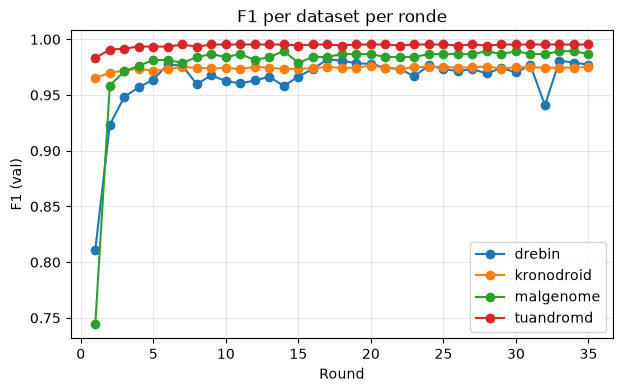

In [6]:
# =============================================================================
# Ekspor CSV: metrik per-ronde (accuracy, precision, recall, f1) + bandwidth
# =============================================================================
# run_federated() sudah otomatis mengekspor ke:
#   FedPer_metrics_per_round.csv   -> loss/accuracy/precision/recall/f1 + bandwidth per ronde
#   FedPer_val_per_client.csv      -> metrik val per client per ronde
# Path-nya juga tersimpan di dalam history:
print("Metrics per-round CSV :", h_fedper.get("metrics_csv_path"))
print("Per-client val CSV    :", h_fedper.get("per_client_csv_path"))

# Kalau mau simpan ke lokasi/nama lain secara eksplisit:
export_history_csv(h_fedper, "FedPer_metrics_per_round.csv")
export_per_client_csv(h_fedper, "FedPer_val_per_client.csv", split="val_per_client")

df_metrics = pd.read_csv("FedPer_metrics_per_round.csv")
print(df_metrics)

# %%
# =============================================================================
# Plot: F1 per dataset per ronde (dari val_per_client)
# =============================================================================
rows = []
for r, vc in zip(h_fedper["round"], h_fedper["val_per_client"]):
    for cname, m in vc.items():
        rows.append({"round": r, "dataset": cname, **m})
df_val = pd.DataFrame(rows)
df_val.to_csv("FedPer_val_per_client_long.csv", index=False)  # versi long-format, opsional

fig, ax = plt.subplots(figsize=(7, 4))
for cname, g in df_val.groupby("dataset"):
    ax.plot(g["round"], g["f1"], marker="o", label=cname)
ax.set_xlabel("Round"); ax.set_ylabel("F1 (val)")
ax.set_title("F1 per dataset per ronde"); ax.legend(); ax.grid(alpha=0.3)
plt.savefig("FedPer_f1_per_round.png", dpi=150, bbox_inches="tight")
plt.show()

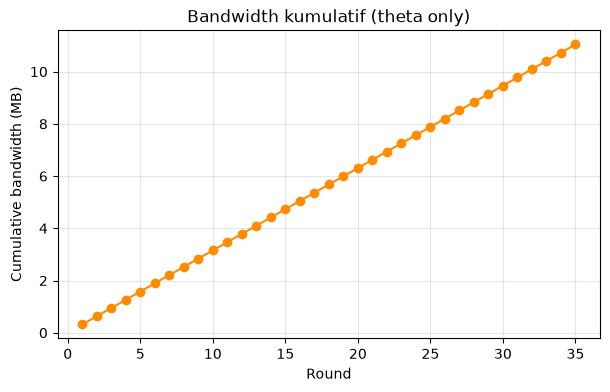

            accuracy  precision  recall      f1
dataset                                        
drebin        0.9867     0.9774  0.9868  0.9821
kronodroid    0.9741     0.9778  0.9731  0.9755
malgenome     0.9807     0.9785  0.9630  0.9707
tuandromd     0.9985     0.9981  1.0000  0.9991

CSV berhasil disimpan sebagai: test_per_client_fedper.csv

Semua file CSV yang dihasilkan:
 - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)
 - FedPer_val_per_client.csv      (metrik val per client per ronde)
 - FedPer_val_per_client_long.csv (versi long-format untuk plotting)
 - test_per_client_fedper.csv     (metrik test akhir per client)


In [7]:
# =============================================================================
# Plot: Bandwidth kumulatif per ronde
# =============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_metrics["round"], df_metrics["cum_MB"], marker="o", color="darkorange")
ax.set_xlabel("Round"); ax.set_ylabel("Cumulative bandwidth (MB)")
ax.set_title("Bandwidth kumulatif (theta only)"); ax.grid(alpha=0.3)
plt.savefig("FedPer_bandwidth_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

# %%
# =============================================================================
# Ringkasan akhir: metrik test per client
# =============================================================================
df_test = pd.DataFrame(h_fedper["test_per_client"]).T
df_test.index.name = "dataset"
df_test = df_test[["accuracy", "precision", "recall", "f1"]].round(4)
print(df_test)

df_test.to_csv("test_per_client_fedper.csv", index=True)
print("\nCSV berhasil disimpan sebagai: test_per_client_fedper.csv")

print("\nSemua file CSV yang dihasilkan:")
print(" - FedPer_metrics_per_round.csv   (metrik + bandwidth per ronde)")
print(" - FedPer_val_per_client.csv      (metrik val per client per ronde)")
print(" - FedPer_val_per_client_long.csv (versi long-format untuk plotting)")
print(" - test_per_client_fedper.csv     (metrik test akhir per client)")